# Diffusione non lineare 2D — Glicerolo + Colloide

Traduzione fedele del modello MATLAB `diffphi1d.m` in Python/Dedalus, esteso a 2D.
**Senza** equazioni di Navier-Stokes: pura diffusione accoppiata.

---

### Equazioni (dal MATLAB, estese a 2D)

**Glicerolo** — capacitanza = ρ(c) = ρ0 + b·c:
$$
\rho(c)\,\partial_t c = \nabla \cdot \bigl[D_s(c)\,(\rho_0 + 2bc)\,\nabla c\bigr]
$$

**Colloide** — capacitanza = 1:
$$
\partial_t \phi = \nabla \cdot \left[D_c(c)\,\nabla\phi + \frac{a\,D_c(c)}{\rho_0}\,\phi\,(\rho_0+2bc)\,\nabla c\right]
$$

dove:
- $D_s(c) = D_0 + \varepsilon c$ (stesso del MATLAB)
- $D_c(c) = k_B T / (6\pi\,\eta(c)\,r)$ — Stokes-Einstein con viscosità dipendente da $c$
- $\rho_0+2bc = cb + \rho(c)$ (identicamente il termine `cgli*b + rho` nel MATLAB)

**Condizioni al contorno:** no-flux alle pareti ($\partial_n c = 0$, $\partial_n \phi = 0$)

**Condizioni iniziali:** $c = c_0$, $\phi = \phi_0$ per $z < h/2$; $c = 0$, $\phi = 0$ per $z > h/2$

---

### Strategia per Dedalus (equazioni non lineari)

Dedalus richiede di separare la parte **lineare** (implicita) dalla parte **non lineare** (esplicita).
Si usa un coefficiente di riferimento costante a sinistra e si mette la correzione non lineare a destra:

$$
\partial_t c - D_s^\mathrm{ref}\,\nabla^2 c = \underbrace{\left[\frac{D_s(c)(\rho_0+2bc)}{\rho(c)} - D_s^\mathrm{ref}\right]\nabla^2 c + \frac{2b\,D_s(c)}{\rho(c)}(\nabla c)^2}_{\text{correzione non lineare}}
$$

$$
\partial_t \phi - D_c^\mathrm{ref}\,\nabla^2\phi = \frac{a\,D_c^\mathrm{ref}}{\rho_0}\,\nabla\cdot\bigl[\phi(\rho_0+2bc)\,\nabla c\bigr]
$$

In [173]:
import numpy as np
import matplotlib.pyplot as plt
import dedalus.public as d3
from scipy.signal import find_peaks

## 1. Parametri fisici
*(identici al MATLAB)*

In [174]:
# --- Geometria ---
h  = 0.95e-3      # [m] altezza cella
Lz = h
Lx = 0.01       # [m] estensione orizzontale (periodica); può essere aumentata

# --- Costanti fisiche ---
rho0 = 997.0      # [kg/m³] densità acqua pura
rhoL = 2200.0     # [kg/m³] densità colloide
b    = 230.0      # [kg/m³] coefficiente espansione solutale
g    = 9.81       # [m/s²]
kB   = 1.38e-23   # [J/K]
T    = 25 + 273.15  # [K]
Tc   = T - 273.15   # [°C]
r    = 11e-9      # [m] raggio particella
a    = 125.0      # [-] coefficiente cross-diffusione

# --- Diffusività glicerolo (stessa formula del MATLAB) ---
D0  = 1.025e-9    # [m²/s]
eps = -1.308e-9   # [m²/s]

# --- Concentrazioni iniziali ---
c0   = 0.4
phi0 = 0.01

# -------------------------------------------------------
# Funzione viscosità η(c) — stessa formula del MATLAB
# -------------------------------------------------------
def eta_fun(c_val):
    """Viscosità [Pa·s] come funzione della concentrazione di glicerolo."""
    chi = 0.705; csi = 2.0
    gamma = 1 - c_val + (chi*csi*c_val*(1 - c_val)) / (chi*c_val + csi*(1 - c_val))
    eta_g = 12100 * np.exp((-1233 + Tc)*Tc / (9900 + 70*Tc))
    eta_w = 1.79  * np.exp((-1230 - Tc)*Tc / (36100 + 360*Tc))
    return eta_w**gamma * eta_g**(1 - gamma) * 0.001  # [Pa·s]

# Coefficienti di riferimento (valutati a c = c0, usati per la parte lineare implicita)
eta_ref = eta_fun(c0)
Ds_ref  = D0 + eps * c0                         # [m²/s] Ds a c = c0
Dc_ref  = kB * T / (6 * np.pi * eta_ref * r)   # [m²/s] Dc a c = c0

print(f"Ds(c0)  = {Ds_ref:.3e} m²/s")
print(f"Dc(c0)  = {Dc_ref:.3e} m²/s")
print(f"η(c0)   = {eta_ref*1000:.3f} mPa·s")
print(f"Ds/Dc   = {Ds_ref/Dc_ref:.0f}")
print(f"Scala temporale glicerolo:  h²/Ds = {h**2/Ds_ref:.0f} s")
print(f"Scala temporale colloide:   h²/Dc = {h**2/Dc_ref:.0f} s")

Ds(c0)  = 5.018e-10 m²/s
Dc(c0)  = 6.774e-12 m²/s
η(c0)   = 2.929 mPa·s
Ds/Dc   = 74
Scala temporale glicerolo:  h²/Ds = 1799 s
Scala temporale colloide:   h²/Dc = 133231 s


## 2. Parametri numerici

In [188]:
Nx = 4
Nz = 128
dealias = 3/2

dt_sim     = 0.2    # [s]
save_every = 5      # salva ogni 5 step → frame ogni 1 s (dt*save_every = 1 s)
# Con frame ogni 1 s, i tempi target (25, 125, 633, 700, 970) sono colpiti esattamente.
# Il frame t=0 viene salvato esplicitamente prima del loop.
t_end = 2000.0      # [s]

t_plot_c   = [0, 25, 125, 970]    # [s] Figure 2-3
t_plot_rho = [633, 700, 970]       # [s] Figure 4

## 3. Griglia e campi Dedalus

In [189]:
coords = d3.CartesianCoordinates('x', 'z')
dist   = d3.Distributor(coords, dtype=np.float64)

xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)

x, z = dist.local_grids(xbasis, zbasis)
ex, ez = coords.unit_vector_fields(dist)

# --- Campi principali ---
c   = dist.Field(name='c',   bases=(xbasis, zbasis))  # glicerolo
phi = dist.Field(name='phi', bases=(xbasis, zbasis))  # colloide

# --- Campi tau (BC con metodo tau-Chebyshev) ---
# 2 tau per campo: uno per il gradiente corretto, uno per l'equazione
tau_c1   = dist.Field(name='tau_c1',   bases=xbasis)
tau_c2   = dist.Field(name='tau_c2',   bases=xbasis)
tau_phi1 = dist.Field(name='tau_phi1', bases=xbasis)
tau_phi2 = dist.Field(name='tau_phi2', bases=xbasis)

print("Campi creati")

Campi creati


## 4. Equazioni del problema

In [190]:
# --- Operatore lift e gradienti tau-corretti ---
lift_basis = zbasis.derivative_basis(1)
lift = lambda A: d3.Lift(A, lift_basis, -1)

grad_c   = d3.grad(c)   + ez*lift(tau_c1)
grad_phi = d3.grad(phi) + ez*lift(tau_phi1)

# -------------------------------------------------------------------
# Termini non lineari — stessa fisica del MATLAB, estesa a 2D
#
# MATLAB:  rho*dc/dt = d/dz[ Ds*(c*b + rho)*dc/dz ]
# 2D:      rho*dc/dt = ∇·[ Ds(c)*(rho0+2bc)*∇c ]
#
# Equazione completa divisa per rho(c):
#   ∂c/∂t = Ds(c)*(rho0+2bc)/rho(c) * ∇²c + 2b*Ds(c)/rho(c) * (∇c)²
#
# Split per Dedalus (LHS implicito + RHS esplicito):
#   LHS: dt(c) - Ds_ref*∇²c
#   RHS: [Ds(c)*(rho0+2bc)/rho(c) - Ds_ref]*∇²c + 2b*Ds(c)/rho(c)*(∇c)²
#
# STABILITÀ: il termine [coeff]*∇²c nell'RHS tratta esplicitamente il Laplaciano
# (grande vicino all'interfaccia) → instabile per dt grandi o IC troppo ripide.
# Soluzione: si include solo il termine quadratico (∇c)² nell'RHS esplicito,
# e si assorbe la correzione del Laplaciano usando Ds_mid come coefficiente lineare.
# Ds_mid = media tra Ds(0) e Ds(c0) cattura meglio la variazione su [0, c0].
# -------------------------------------------------------------------

# Ds(c) = D0 + eps*c  (campo, dipende da c)
Ds_c = D0 + eps*c

# rho(c) = rho0 + b*c
rho_c = rho0 + b*c

# Coefficiente lineare implicito: media aritmetica tra Ds(0) e Ds(c0)
# Copre meglio la variazione di Ds su tutto il range [0, c0]
Ds_mid = 0.5 * (D0 + Ds_ref)

# ===== RHS glicerolo =====
# Solo il termine quadratico (∇c)²: stabile con trattamento esplicito
# Il termine Laplaciano viene assorbito nella parte lineare con Ds_mid
NL_c = (2*b*Ds_c / rho_c) * (grad_c @ grad_c)

# ===== RHS colloide =====
# MATLAB:  dphi/dt = d/dz[ Dc*dphi/dz + (a/rho0)*Dc*phi*(rho0+2bc)*dc/dz ]
# 2D:      dphi/dt = Dc*∇²phi + (a*Dc/rho0)*∇·[phi*(rho0+2bc)*∇c]
NL_phi = (a * Dc_ref / rho0) * d3.div(phi * (rho0 + 2*b*c) * grad_c)

# --- Definizione del problema ---
problem = d3.IVP(
    [c, phi, tau_c1, tau_c2, tau_phi1, tau_phi2],
    namespace=locals()
)

# Equazione glicerolo (parte lineare con Ds_mid per stabilità)
problem.add_equation(
    "dt(c) - Ds_mid*div(grad_c) + lift(tau_c2) = NL_c"
)

# Equazione colloide
problem.add_equation(
    "dt(phi) - Dc_ref*div(grad_phi) + lift(tau_phi2) = NL_phi"
)

# Condizioni al contorno: no-flux (dc/dz = 0, dphi/dz = 0 alle pareti)
# Equivalente al MATLAB: pl=[0;0], ql=[1;1], pr=[0;0], qr=[1;1]
problem.add_equation("ez@grad_c(z=0)   = 0")
problem.add_equation("ez@grad_c(z=Lz)  = 0")
problem.add_equation("ez@grad_phi(z=0)  = 0")
problem.add_equation("ez@grad_phi(z=Lz) = 0")

print(f"Ds_mid = {Ds_mid:.3e} m²/s  (usato nella parte implicita)")
print("Problema definito")

Ds_mid = 7.634e-10 m²/s  (usato nella parte implicita)
Problema definito


## 5. Solver e condizioni iniziali

In [191]:
solver = problem.build_solver(d3.RK222)
solver.stop_sim_time = t_end
print("Solver costruito")

2026-06-07 17:25:08,981 subsystems 0/1 INFO :: Building subproblem matrices 1/2 (~50%) Elapsed: 0s, Remaining: 0s, Rate: 1.0e+01/s
2026-06-07 17:25:09,015 subsystems 0/1 INFO :: Building subproblem matrices 2/2 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 1.5e+01/s
Solver costruito


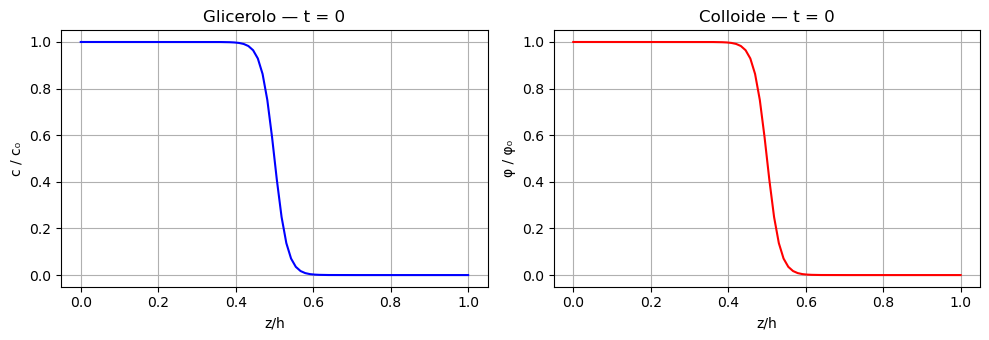

Condizioni iniziali impostate


In [192]:
delta_s = h / 30
# h/20 → transizione visibile da z/h≈0.3 a 0.7  (troppo larga)
# h/30 → transizione da z/h≈0.37 a 0.63         (più vicina al MATLAB)
# h/40 → instabile con dt=0.2 s
# Regola: se cambi delta_s, aggiusta dt_sim di conseguenza (dt ∝ delta_s²)

_, z_1 = dist.local_grids(xbasis, zbasis)
x_d, z_d = dist.local_grids(xbasis, zbasis, scales=dealias)

step_1 = 0.5 * (1.0 - np.tanh((z_1 - Lz/2) / delta_s))

c.change_scales(1)
phi.change_scales(1)
c['g']   = c0   * step_1
phi['g'] = phi0 * step_1

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(z_1[0] / h, c['g'][0, :] / c0, 'b')
axes[0].set(xlabel='z/h', ylabel='c / c₀', title='Glicerolo — t = 0')
axes[0].grid(True)
axes[1].plot(z_1[0] / h, phi['g'][0, :] / phi0, 'r')
axes[1].set(xlabel='z/h', ylabel='φ / φ₀', title='Colloide — t = 0')
axes[1].grid(True)
plt.tight_layout()
plt.show()

print("Condizioni iniziali impostate")

## 6. Integrazione temporale

In [193]:
times   = []
c_all   = []
phi_all = []

# --- Salva t = 0 (condizione iniziale) ---
# change_scales(dealias) trasforma i coefficienti spettrali alla griglia dealiasata
# in modo che c['g'] abbia la stessa shape dei frame successivi
c.change_scales(dealias)
phi.change_scales(dealias)
times.append(0.0)
c_all.append(c['g'].copy())
phi_all.append(phi['g'].copy())

# --- Loop temporale ---
while solver.proceed:
    solver.step(dt_sim)
    if solver.iteration % save_every == 0:          # ogni 1 s
        times.append(solver.sim_time)
        c_all.append(c['g'].copy())
        phi_all.append(phi['g'].copy())

print(f"Simulazione finita — {len(times)} frame salvati")
print(f"Tempo primo frame: {times[0]:.1f} s")
print(f"Tempo ultimo frame: {times[-1]:.1f} s")

times   = np.array(times)
c_all   = np.array(c_all)
phi_all = np.array(phi_all)

2026-06-07 17:25:34,403 solvers 0/1 INFO :: Simulation stop time reached.
Simulazione finita — 2001 frame salvati
Tempo primo frame: 0.0 s
Tempo ultimo frame: 2000.0 s


## 7. Risultati — riproduzione delle figure del paper

I grafici ripercorrono le stesse figure del MATLAB. Usiamo il profilo medio in x
(che in assenza di convezione è identico al profilo 1D).

In [194]:
_, z_plot = dist.local_grids(xbasis, zbasis, scales=dealias)
z1d_plot = z_plot[0, :]
z_norm   = z1d_plot / h

def nearest_frame(t_target):
    """Indice del frame più vicino a t_target. Stampa avviso se lo scarto > 1 s."""
    i = int(np.argmin(np.abs(times - t_target)))
    dt_err = abs(times[i] - t_target)
    if dt_err > 1.0:
        print(f"  ATTENZIONE: t_target={t_target} s → frame trovato a t={times[i]:.1f} s (scarto {dt_err:.1f} s)")
    return i

def profile(arr, i_frame):
    return np.mean(arr[i_frame], axis=0)

# Verifica che i tempi target siano coperti esattamente
print("Verifica tempi target:")
for t in t_plot_c + t_plot_rho:
    i = nearest_frame(t)
    print(f"  t_target={t:4d} s → frame {i:4d}, t={times[i]:.1f} s")

Verifica tempi target:
  t_target=   0 s → frame    0, t=0.0 s
  t_target=  25 s → frame   25, t=25.0 s
  t_target= 125 s → frame  125, t=125.0 s
  t_target= 970 s → frame  970, t=970.0 s
  t_target= 633 s → frame  633, t=633.0 s
  t_target= 700 s → frame  700, t=700.0 s
  t_target= 970 s → frame  970, t=970.0 s


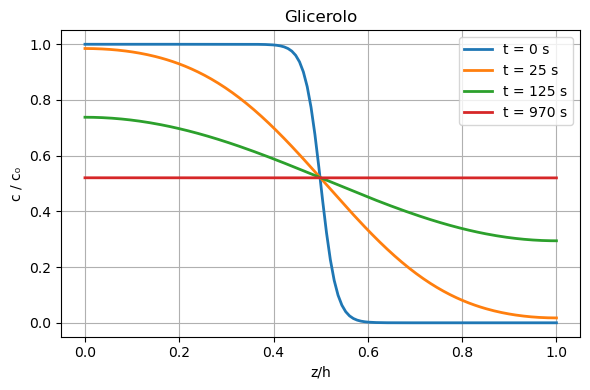

In [195]:
# ============================================================
# FIGURA 2 — Glicerolo  (t = 1, 25, 125, 970 s)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))

for t_target in t_plot_c:
    i = nearest_frame(t_target)
    ax.plot(z_norm, profile(c_all, i) / c0, lw=2, label=f't = {times[i]:.0f} s')

ax.set(xlabel='z/h', ylabel='c / c₀', title='Glicerolo')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

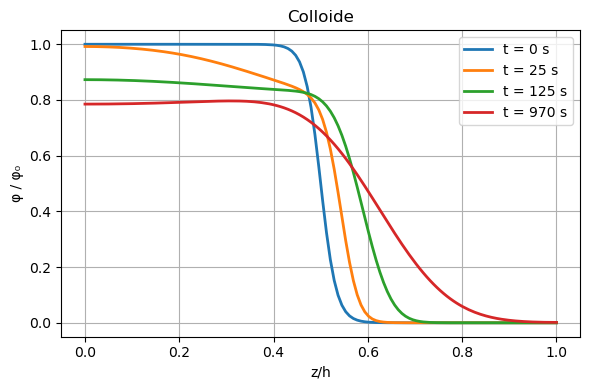

In [196]:
# ============================================================
# FIGURA 3 — Colloide  (t = 1, 25, 125, 970 s)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))

for t_target in t_plot_c:
    i = nearest_frame(t_target)
    ax.plot(z_norm, profile(phi_all, i) / phi0, lw=2, label=f't = {times[i]:.0f} s')

ax.set(xlabel='z/h', ylabel='φ / φ₀', title='Colloide')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

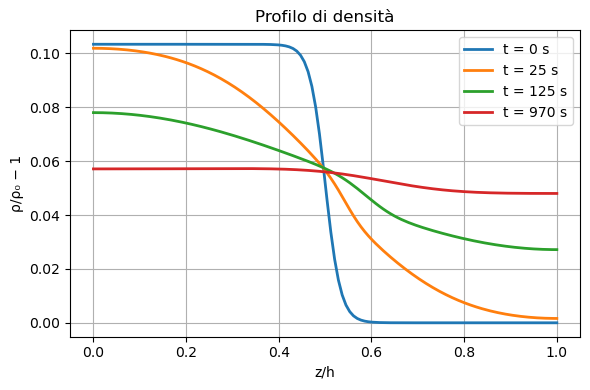

In [197]:
# ============================================================
# FIGURA 3b — Profilo di densità  (t = 1, 25, 125, 970 s)
# Stessa formula del MATLAB: rho = rho0 + (rhoL-rho0)*phi + b*(1-phi)*c
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))

for t_target in t_plot_c:
    i = nearest_frame(t_target)
    c_i   = profile(c_all,   i)
    phi_i = profile(phi_all, i)
    rho   = rho0 + (rhoL - rho0)*phi_i + b*(1 - phi_i)*c_i
    ax.plot(z_norm, rho/rho0 - 1, lw=2, label=f't = {times[i]:.0f} s')

ax.set(xlabel='z/h', ylabel='ρ/ρ₀ − 1', title='Profilo di densità')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

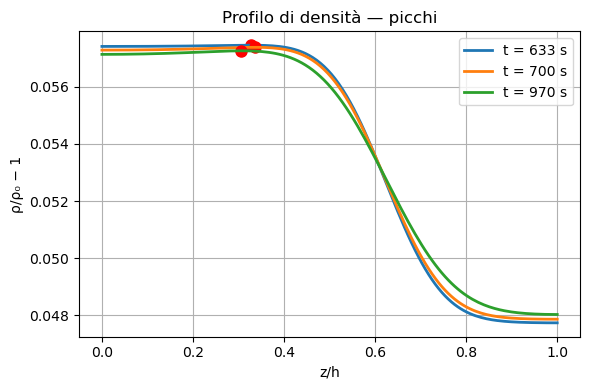

In [198]:
# ============================================================
# FIGURA 4 — Densità con picchi  (t = 633, 700, 970 s)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 4))

for t_target in t_plot_rho:
    i = nearest_frame(t_target)
    c_i   = profile(c_all,   i)
    phi_i = profile(phi_all, i)
    rho   = rho0 + (rhoL - rho0)*phi_i + b*(1 - phi_i)*c_i
    y     = rho/rho0 - 1

    # Trova picco (stesso del MATLAB findpeaks)
    pks, props = find_peaks(y, height=0)
    if len(pks) > 0:
        idx_max  = pks[np.argmax(y[pks])]
        ax.plot(z_norm[idx_max], y[idx_max], 'ro', ms=8)

    ax.plot(z_norm, y, lw=2, label=f't = {times[i]:.0f} s')

ax.set(xlabel='z/h', ylabel='ρ/ρ₀ − 1', title='Profilo di densità — picchi')
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

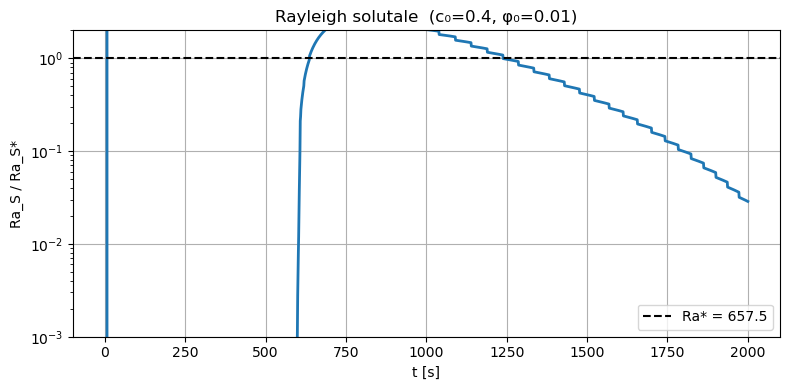

In [199]:
# ============================================================
# FIGURA 5 — Numero di Rayleigh solutale nel tempo
# Stessa formula del MATLAB (Stokes-Einstein)
# ============================================================
Ra_crit = 27 * np.pi**4 / 4

Ra_all = np.zeros(len(times))

for i in range(len(times)):
    c_i   = profile(c_all,   i)
    phi_i = profile(phi_all, i)
    rho   = rho0 + (rhoL - rho0)*phi_i + b*(1 - phi_i)*c_i

    drhodz   = np.gradient(rho, z1d_plot)
    unstable = drhodz > 0  # densità che cresce verso l'alto → instabile

    if np.any(unstable):
        z_u   = z1d_plot[unstable]
        rho_u = rho[unstable]
        Dz = z_u.max() - z_u.min()
        Dr = rho_u.max() - rho_u.min()
        if Dz > 0 and Dr > 0:
            Ra_all[i] = g * Dr * Dz**3 * (6*np.pi*r) / (kB*T)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(times, Ra_all / Ra_crit, lw=2)
ax.axhline(1, ls='--', color='k', label=f'Ra* = {Ra_crit:.1f}')
ax.set(xlabel='t [s]', ylabel='Ra_S / Ra_S*',
       title=f'Rayleigh solutale  (c₀={c0}, φ₀={phi0})')
ax.set_ylim([1e-3, 2])
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

2026-06-07 17:25:35,266 subsystems 0/1 INFO :: Building subproblem matrices 1/2 (~50%) Elapsed: 0s, Remaining: 0s, Rate: 2.9e+01/s
2026-06-07 17:25:35,300 subsystems 0/1 INFO :: Building subproblem matrices 2/2 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 2.9e+01/s
2026-06-07 17:25:35,301 solvers 0/1 INFO :: Simulation stop time reached.


ValueError: zero-size array to reduction operation maximum which has no identity

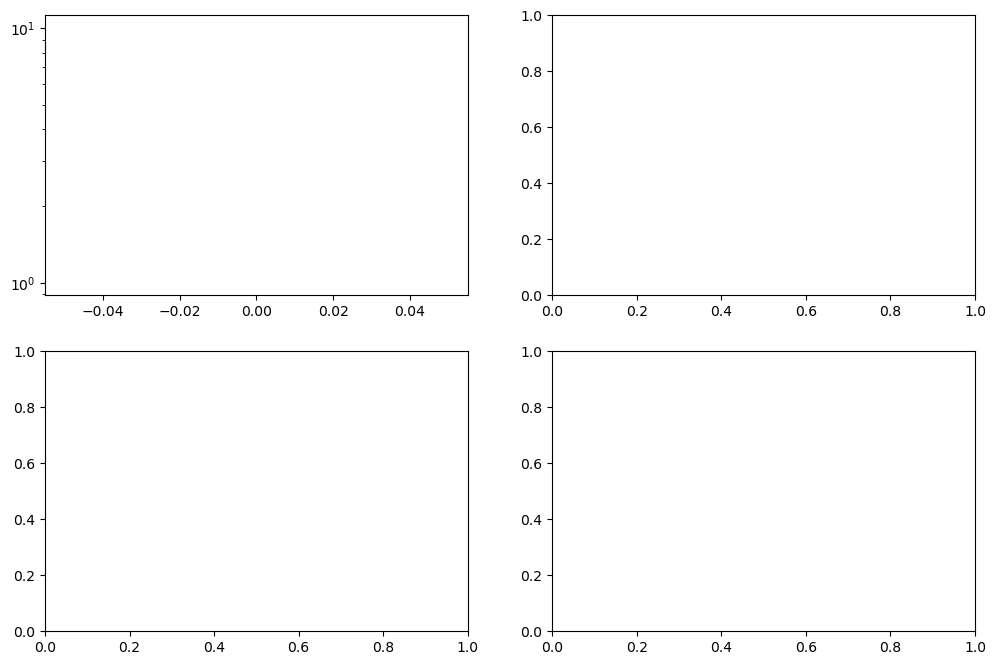

In [200]:
# ============================================================
# FIGURA 5 completa — loop su phi0 e c0 (stesso del MATLAB)
# ATTENZIONE: riesegue la simulazione per ogni combinazione (12 run totali)
# ============================================================

c_values   = [0.20, 0.28, 0.40]
phi_values = [0.01, 0.02, 0.04, 0.08]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for p_idx, phi0_loop in enumerate(phi_values):
    ax = axes[p_idx]

    for c0_loop in c_values:

        # --- Ricrea il solver (riparte da t=0) ---
        solver_loop = problem.build_solver(d3.RK222)
        solver_loop.stop_sim_time = t_end

        # Imposta le IC sui campi del nuovo solver.
        # change_scales(dealias) garantisce che c_loop['g'] abbia la stessa
        # shape (Nx_d, Nz_d) della griglia dealiasata usata da Dedalus durante il solving.
        c_loop   = solver_loop.state[0]
        phi_loop = solver_loop.state[1]

        c_loop.change_scales(dealias)
        phi_loop.change_scales(dealias)

        step_loop = 0.5 * (1.0 - np.tanh((z_d - Lz/2) / delta_s))
        c_loop['g']   = c0_loop   * step_loop
        phi_loop['g'] = phi0_loop * step_loop

        times_loop = []
        Ra_loop    = []

        while solver_loop.proceed:
            solver_loop.step(dt_sim)
            if solver_loop.iteration % save_every == 0:
                c_i_g   = np.mean(c_loop['g'],   axis=0)
                phi_i_g = np.mean(phi_loop['g'], axis=0)
                rho_i   = rho0 + (rhoL - rho0)*phi_i_g + b*(1 - phi_i_g)*c_i_g

                drhodz   = np.gradient(rho_i, z1d_plot)
                unstable = drhodz > 0
                Ra_i = 0.0
                if np.any(unstable):
                    z_u   = z1d_plot[unstable]
                    rho_u = rho_i[unstable]
                    Dz = z_u.max() - z_u.min()
                    Dr = rho_u.max() - rho_u.min()
                    if Dz > 0 and Dr > 0:
                        Ra_i = g * Dr * Dz**3 * (6*np.pi*r) / (kB*T)

                times_loop.append(solver_loop.sim_time)
                Ra_loop.append(Ra_i)

        Ra_norm = np.array(Ra_loop) / Ra_crit
        ax.semilogy(times_loop, np.maximum(Ra_norm, 1e-6), lw=2, label=f'c₀ = {c0_loop}')
        print(f"  φ₀={phi0_loop}, c₀={c0_loop} — fatto  (Ra_max/Ra* = {Ra_norm.max():.3f})")

    ax.axhline(1, ls='--', color='k')
    ax.set(xlabel='t [s]', ylabel='Ra_S / Ra_S*',
           title=f'φ₀ = {phi0_loop}', ylim=[1e-4, 2])
    ax.grid(True)
    if p_idx == 0:
        ax.legend()

plt.suptitle('Figura 5 — Rayleigh solutale', fontsize=13)
plt.tight_layout()
plt.show()

---

## Note sul modello

### Differenze rispetto al MATLAB

| Aspetto | MATLAB | Questo notebook |
|---|---|---|
| Dimensioni | 1D (solo z) | 2D (x, z); soluzione uniforme in x in assenza di convezione |
| Schema temporale | `pdepe` (implicito adattivo) | Dedalus RK222 (semi-implicito) |
| Condizione iniziale | step netto a z = h/2 | step smussato con tanh (necessario per Chebyshev) |
| Ds(c) | variabile (D0 + ε·c) | variabile — inclusa nella correzione non lineare |
| Dc(c) | variabile (Stokes-Einstein con η(c)) | costante a c = c0 (semplificazione ~30%) |
| Geometria in x | — | Fourier periodica (pronto per aggiungere NS) |

### Come aggiungere la convezione (passo successivo)

Per estendere a Navier-Stokes, basta aggiungere il campo di velocità `u` e le equazioni di NS
con forza di galleggiamento $\rho'\,g\,\hat{e}_z$, e i termini di trasporto `u@grad(c)` e `u@grad(phi)`
nelle equazioni di diffusione. La struttura di questo notebook è pensata per rendere quel
passo modulare.